# Power Consumption Prediction — Zone 3 (EDA)

In [1]:
import os
os.getcwd()

'C:\\Users\\PC'

In [2]:
os.chdir(r"D:\FQL\PJ 6")

## Section 1 : Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
PALETTE = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657', '#79c0ff']

print('Libraries loaded successfully')

Libraries loaded successfully


## Section 2 : Data load & Inspection

In [5]:
# Load Dataset 
df = pd.read_csv('powerconsumption.csv', parse_dates=['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

print(f'Dataset shape  : {df.shape}')
print(f'Date range     : {df["Datetime"].min()} → {df["Datetime"].max()}')
print(f'Total records  : {len(df):,}')
print(f'Columns        : {list(df.columns)}')
df.head(10)

Dataset shape  : (52416, 9)
Date range     : 2017-01-01 00:00:00 → 2017-12-30 23:50:00
Total records  : 52,416
Columns        : ['Datetime', 'Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964
5,2017-01-01 00:50:00,5.853,76.9,0.081,0.059,0.108,26624.81013,17416.41337,18130.12048
6,2017-01-01 01:00:00,5.641,77.7,0.080,0.048,0.096,25998.98734,16993.31307,17945.06024
7,2017-01-01 01:10:00,5.496,78.2,0.085,0.055,0.093,25446.07595,16661.39818,17459.27711
8,2017-01-01 01:20:00,5.678,78.1,0.081,0.066,0.141,24777.72152,16227.35562,17025.54217
9,2017-01-01 01:30:00,5.491,77.3,0.082,0.062,0.111,24279.49367,15939.20973,16794.21687


In [6]:
# Data Types & Summary
print('\n=== DTYPES ===')
print(df.dtypes)
print('\n=== DESCRIPTIVE STATISTICS ===')
df.describe().T.style.background_gradient(cmap='Blues')


=== DTYPES ===
Datetime                  datetime64[ns]
Temperature                      float64
Humidity                         float64
WindSpeed                        float64
GeneralDiffuseFlows              float64
DiffuseFlows                     float64
PowerConsumption_Zone1           float64
PowerConsumption_Zone2           float64
PowerConsumption_Zone3           float64
dtype: object

=== DESCRIPTIVE STATISTICS ===


,count,mean,min,25%,50%,75%,max,std
Datetime,52416,2017-07-01 23:55:00,2017-01-01 00:00:00,2017-04-01 23:57:30,2017-07-01 23:55:00,2017-09-30 23:52:30,2017-12-30 23:50:00,nan
Temperature,52416.000000,18.810024,3.247000,14.410000,18.780000,22.890000,40.010000,5.815476
Humidity,52416.000000,68.259518,11.340000,58.310000,69.860000,81.400000,94.800000,15.551177
WindSpeed,52416.000000,1.959489,0.050000,0.078000,0.086000,4.915000,6.483000,2.348862
GeneralDiffuseFlows,52416.000000,182.696614,0.004000,0.062000,5.035500,319.600000,1163.000000,264.400960
DiffuseFlows,52416.000000,75.028022,0.011000,0.122000,4.456000,101.000000,936.000000,124.210949
PowerConsumption_Zone1,52416.000000,32344.970564,13895.696200,26310.668692,32265.920340,37309.018185,52204.395120,7130.562564
PowerConsumption_Zone2,52416.000000,21042.509082,8560.081466,16980.766032,20823.168405,24713.717520,37408.860760,5201.465892
PowerConsumption_Zone3,52416.000000,17835.406218,5935.174070,13129.326630,16415.117470,21624.100420,47598.326360,6622.165099


## Section 3 : Missing Values & Data Quality

In [7]:
# Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

                        Missing Count  Missing %
Datetime                            0        0.0
Temperature                         0        0.0
Humidity                            0        0.0
WindSpeed                           0        0.0
GeneralDiffuseFlows                 0        0.0
DiffuseFlows                        0        0.0
PowerConsumption_Zone1              0        0.0
PowerConsumption_Zone2              0        0.0
PowerConsumption_Zone3              0        0.0


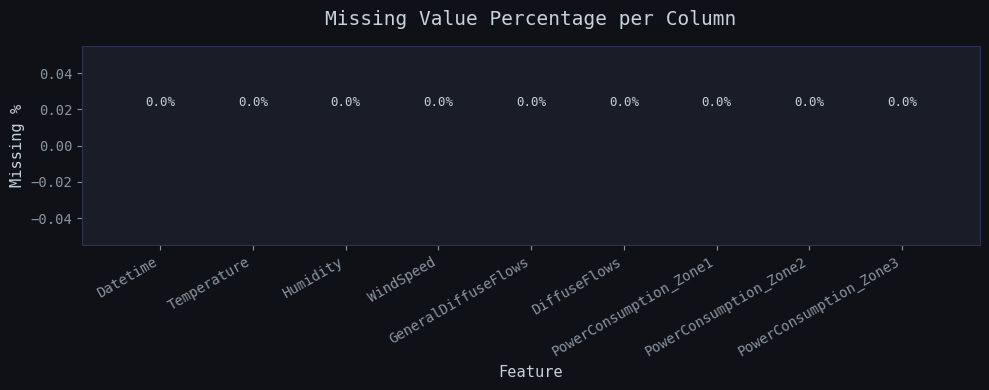


 No leakage risk — no ID columns present in this dataset.


In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#f78166' if v > 0 else '#3fb950' for v in missing_pct.values]
bars = ax.bar(missing_pct.index, missing_pct.values, color=colors, edgecolor='none')
ax.set_title('Missing Value Percentage per Column', fontsize=14, pad=15)
ax.set_ylabel('Missing %')
ax.set_xlabel('Feature')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color='#c9d1d9')
plt.tight_layout()
plt.savefig('plots/01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n No leakage risk — no ID columns present in this dataset.')

In [9]:
# Duplicate Check
dupes = df.duplicated().sum()
datetime_dupes = df.duplicated(subset=['Datetime']).sum()
print(f'Duplicate rows       : {dupes}')
print(f'Duplicate Datetimes  : {datetime_dupes}')

Duplicate rows       : 0
Duplicate Datetimes  : 0


In [10]:
# Expected vs Actual Records 
expected = int((df['Datetime'].max() - df['Datetime'].min()).total_seconds() / 600) + 1
print(f'Expected 10-min rows : {expected:,}')
print(f'Actual rows          : {len(df):,}')
print(f'Gap rows             : {expected - len(df):,}')

Expected 10-min rows : 52,416
Actual rows          : 52,416
Gap rows             : 0


## Section 4 : Feature Distributions

In [11]:
print(f'Columns        : {list(df.columns)}')

Columns        : ['Datetime', 'Temperature', 'Humidity', 'WindSpeed', 'GeneralDiffuseFlows', 'DiffuseFlows', 'PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']


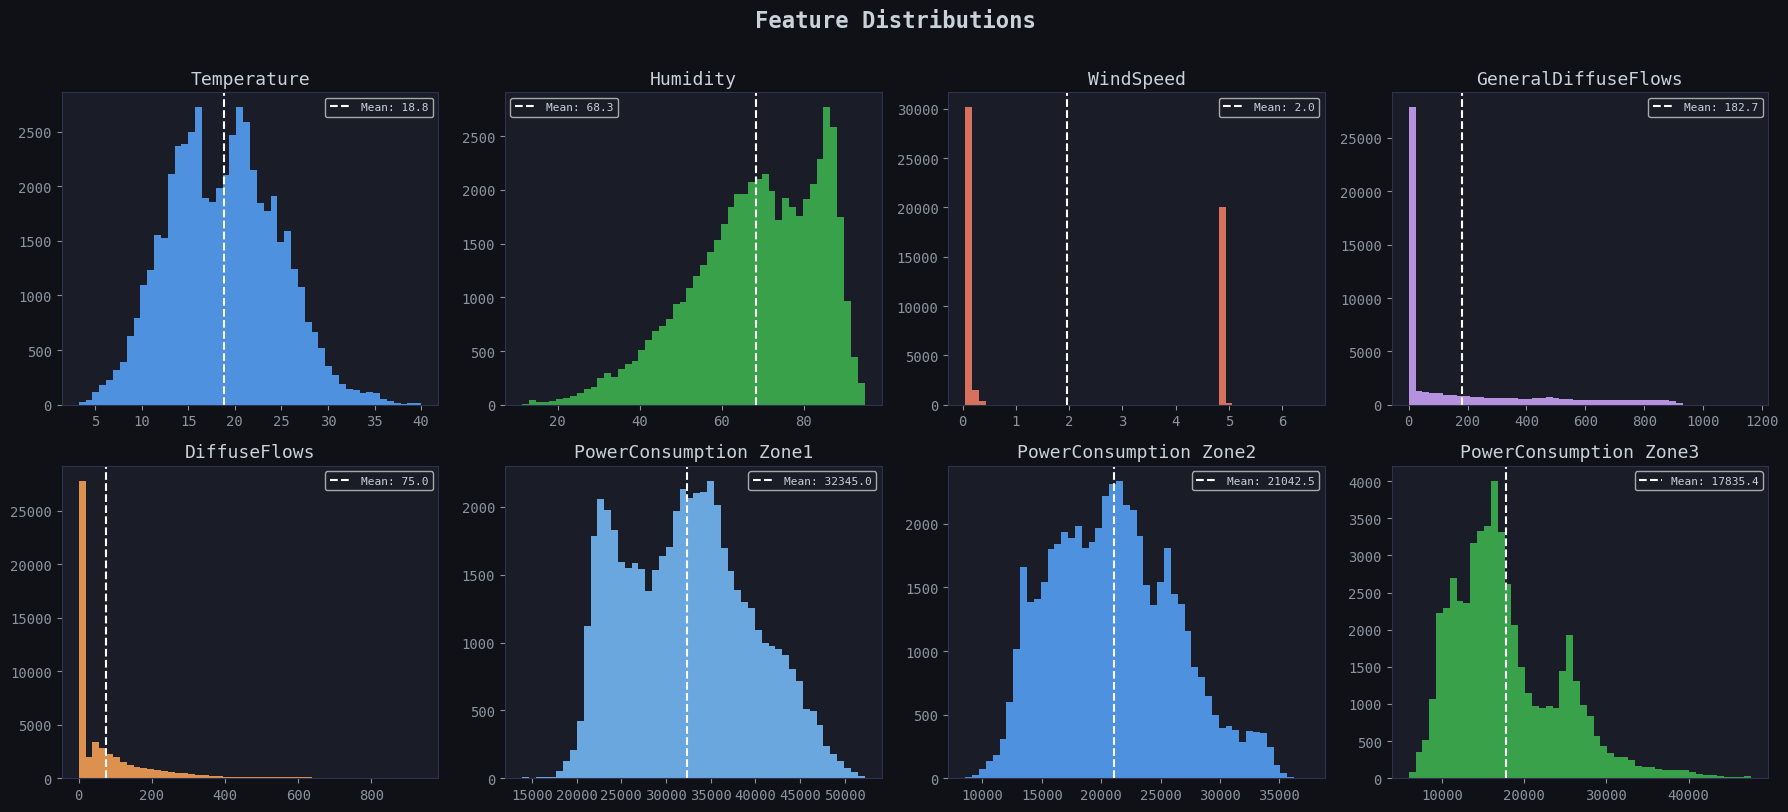

In [12]:
features = ['Temperature', 'Humidity', 'WindSpeed',
            'GeneralDiffuseFlows', 'DiffuseFlows',
            'PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    color = PALETTE[i % len(PALETTE)]
    axes[i].hist(df[feat].dropna(), bins=50, color=color, alpha=0.85, edgecolor='none')
    axes[i].axvline(df[feat].mean(), color='white', linewidth=1.5, linestyle='--', label=f'Mean: {df[feat].mean():.1f}')
    axes[i].set_title(feat.replace('_', ' '))
    axes[i].legend(fontsize=8)

fig.suptitle('Feature Distributions', fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

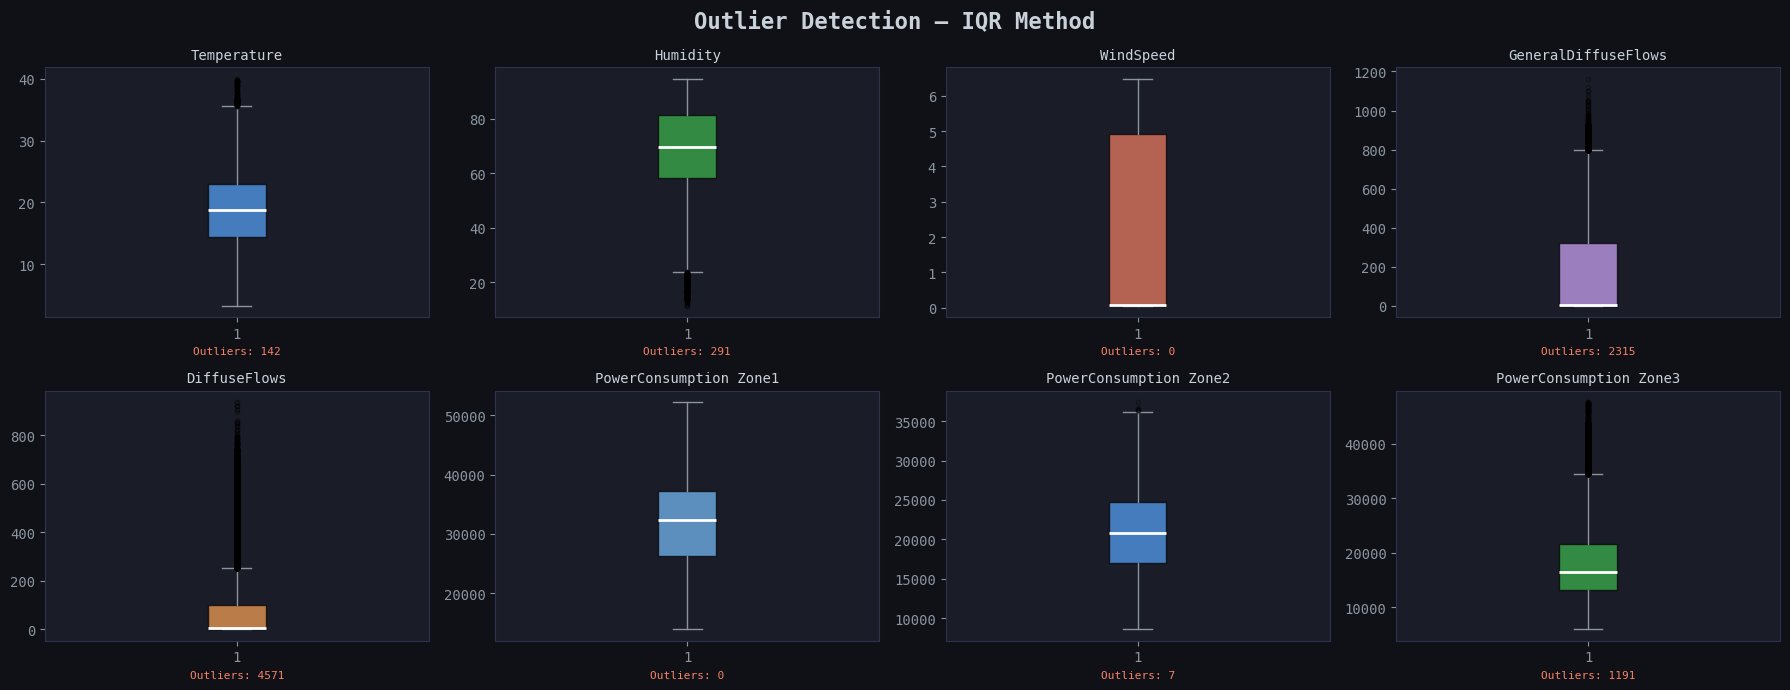

In [13]:
# Box Plots for Outlier Detection
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, feat in enumerate(features):
    color = PALETTE[i % len(PALETTE)]
    bp = axes[i].boxplot(df[feat].dropna(), patch_artist=True,
                          boxprops=dict(facecolor=color, alpha=0.7),
                          medianprops=dict(color='white', linewidth=2),
                          whiskerprops=dict(color='#8b949e'),
                          capprops=dict(color='#8b949e'),
                          flierprops=dict(marker='o', color='#f78166', alpha=0.3, markersize=3))
    axes[i].set_title(feat.replace('_', ' '), fontsize=10)
    q1, q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df[feat] < q1 - 1.5*iqr) | (df[feat] > q3 + 1.5*iqr)).sum()
    axes[i].set_xlabel(f'Outliers: {outliers}', fontsize=8, color='#f78166')

fig.suptitle('Outlier Detection — IQR Method', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 : Temporal Patterns

In [14]:
# Extract Time Features for Analysis
df['Hour']    = df['Datetime'].dt.hour
df['Month']   = df['Datetime'].dt.month
df['DayOfWeek'] = df['Datetime'].dt.dayofweek
df['Season']  = df['Month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring',  4:'Spring', 5:'Spring',
    6:'Summer',  7:'Summer', 8:'Summer',
    9:'Autumn',  10:'Autumn', 11:'Autumn'
})
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

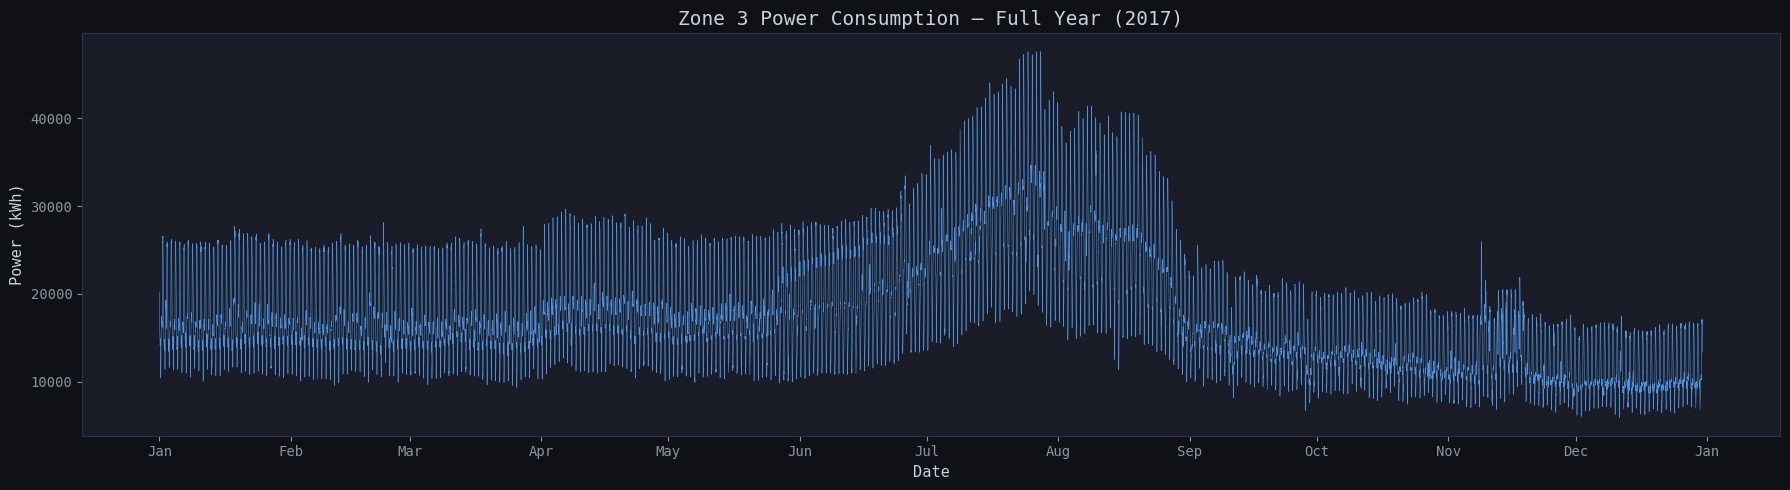

In [15]:
# Full Time-Series Plot 
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(df['Datetime'], df['PowerConsumption_Zone3'],
        color='#58a6ff', linewidth=0.4, alpha=0.85)
ax.set_title('Zone 3 Power Consumption — Full Year (2017)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Power (kWh)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.tight_layout()
plt.savefig('plots/04_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

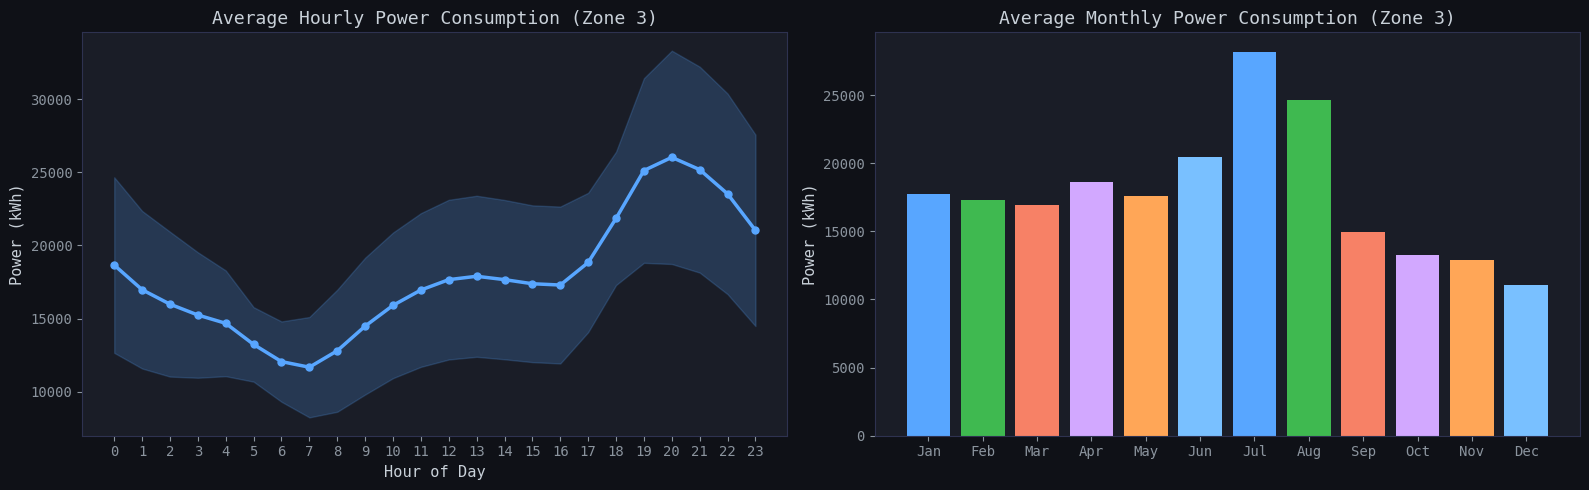

In [16]:
# Hourly Pattern 
hourly = df.groupby('Hour')['PowerConsumption_Zone3'].agg(['mean','std']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hourly mean
axes[0].plot(hourly['Hour'], hourly['mean'], color='#58a6ff', linewidth=2.5, marker='o', markersize=5)
axes[0].fill_between(hourly['Hour'],
                      hourly['mean'] - hourly['std'],
                      hourly['mean'] + hourly['std'],
                      alpha=0.2, color='#58a6ff')
axes[0].set_title('Average Hourly Power Consumption (Zone 3)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Power (kWh)')
axes[0].set_xticks(range(0, 24))

# Monthly mean
monthly = df.groupby('Month')['PowerConsumption_Zone3'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bars = axes[1].bar(range(1, 13), monthly.values, color=PALETTE * 2, edgecolor='none')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_title('Average Monthly Power Consumption (Zone 3)')
axes[1].set_ylabel('Power (kWh)')

plt.tight_layout()
plt.savefig('plots/05_hourly_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

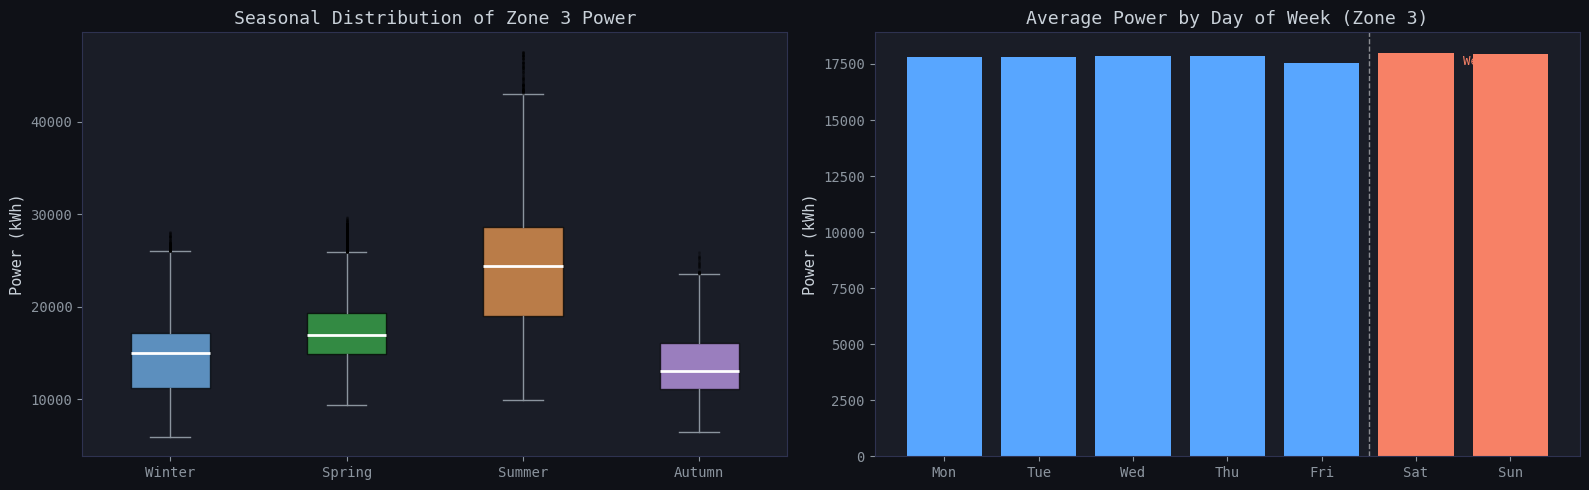

In [18]:
# Seasonal & Weekday/Weekend Patterns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Season box plot
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colors = ['#79c0ff', '#3fb950', '#ffa657', '#d2a8ff']
season_data = [df[df['Season'] == s]['PowerConsumption_Zone3'].dropna() for s in season_order]
bp = axes[0].boxplot(season_data, labels=season_order, patch_artist=True,
                      medianprops=dict(color='white', linewidth=2),
                      whiskerprops=dict(color='#8b949e'),
                      capprops=dict(color='#8b949e'),
                      flierprops=dict(marker='.', alpha=0.2, markersize=2))
for patch, color in zip(bp['boxes'], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Seasonal Distribution of Zone 3 Power')
axes[0].set_ylabel('Power (kWh)')

# Weekday vs Weekend
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily_avg = df.groupby('DayOfWeek')['PowerConsumption_Zone3'].mean()
colors_day = ['#58a6ff']*5 + ['#f78166']*2
axes[1].bar(day_labels, daily_avg.values, color=colors_day, edgecolor='none')
axes[1].set_title('Average Power by Day of Week (Zone 3)')
axes[1].set_ylabel('Power (kWh)')
axes[1].axvline(4.5, color='white', linestyle='--', linewidth=1, alpha=0.5)
axes[1].text(5.5, daily_avg.max()*0.97, 'Weekend', color='#f78166', fontsize=9)

plt.tight_layout()
plt.savefig('plots/06_seasonal_weekly.png', dpi=150, bbox_inches='tight')
plt.show()

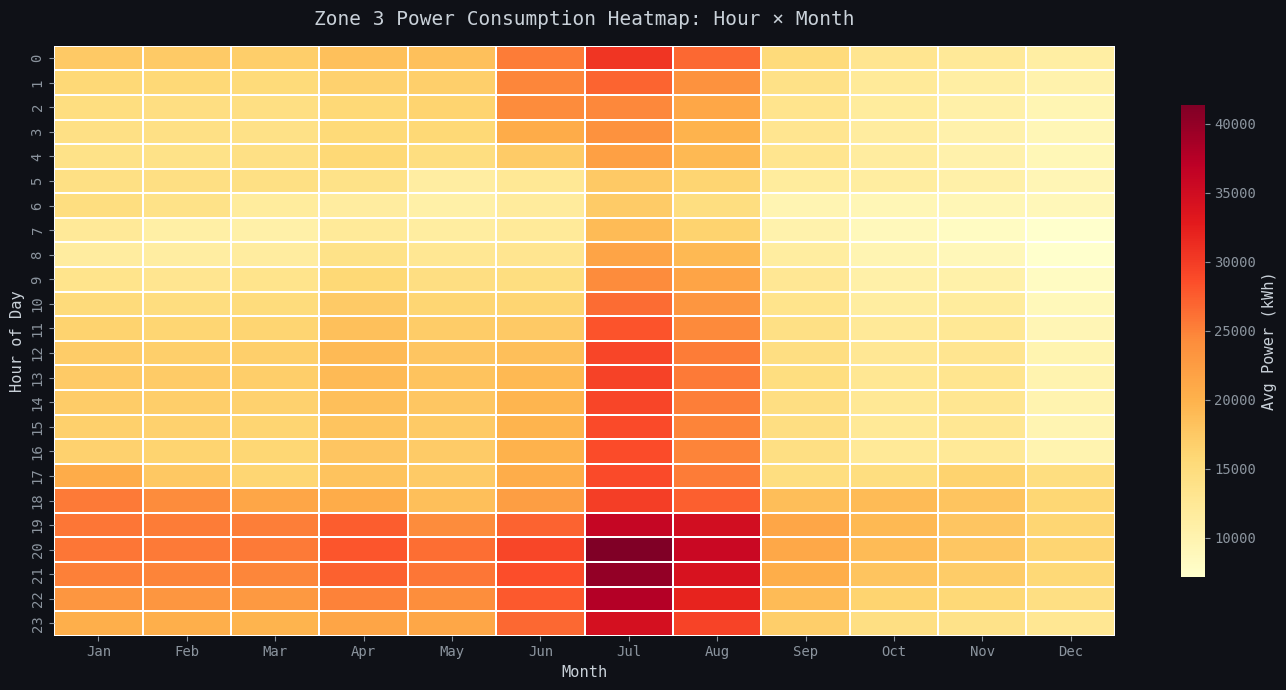

In [19]:
# Heatmap: Hour vs Month 
pivot = df.pivot_table(values='PowerConsumption_Zone3', index='Hour', columns='Month', aggfunc='mean')
pivot.columns = month_names

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Avg Power (kWh)', 'shrink': 0.8},
            annot=False, fmt='.0f')
ax.set_title('Zone 3 Power Consumption Heatmap: Hour × Month', fontsize=14, pad=15)
ax.set_ylabel('Hour of Day')
ax.set_xlabel('Month')
plt.tight_layout()
plt.savefig('plots/07_heatmap_hour_month.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 : Correlation Analysis

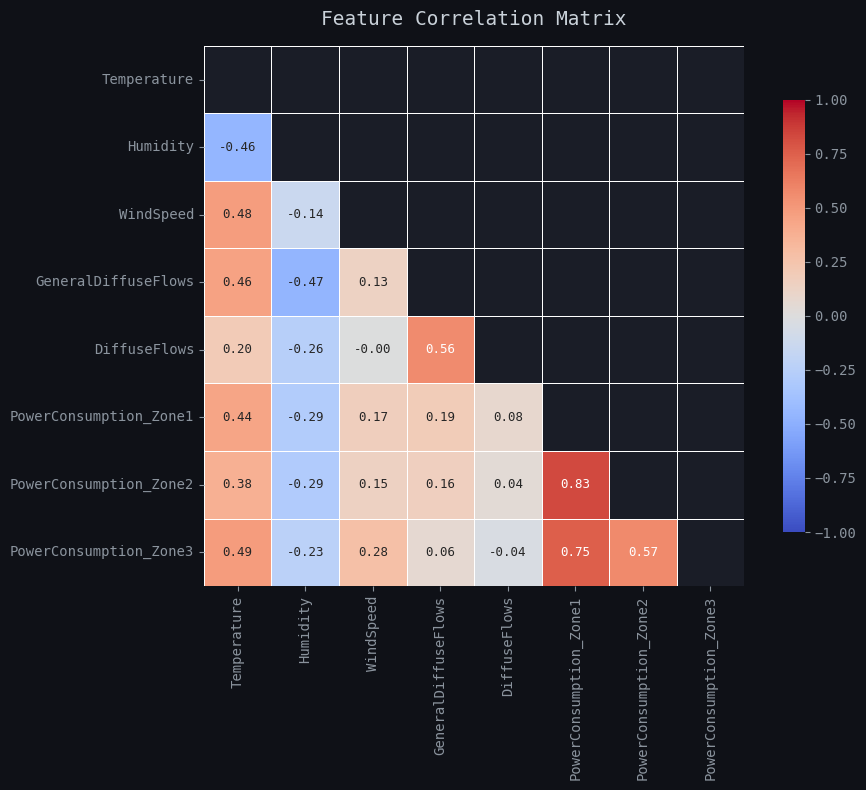

In [21]:
# Correlation Heatmap 
numeric_cols = ['Temperature', 'Humidity', 'WindSpeed',
                'GeneralDiffuseFlows', 'DiffuseFlows',
                'PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='coolwarm', vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('plots/08_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Correlation with target
print('\n=== Correlation with PowerConsumption_Zone3 ===')
print(corr['PowerConsumption_Zone3'].drop('PowerConsumption_Zone3').sort_values(ascending=False))


=== Correlation with PowerConsumption_Zone3 ===
PowerConsumption_Zone1    0.750733
PowerConsumption_Zone2    0.570932
Temperature               0.489527
WindSpeed                 0.278641
GeneralDiffuseFlows       0.063376
DiffuseFlows             -0.038506
Humidity                 -0.233022
Name: PowerConsumption_Zone3, dtype: float64


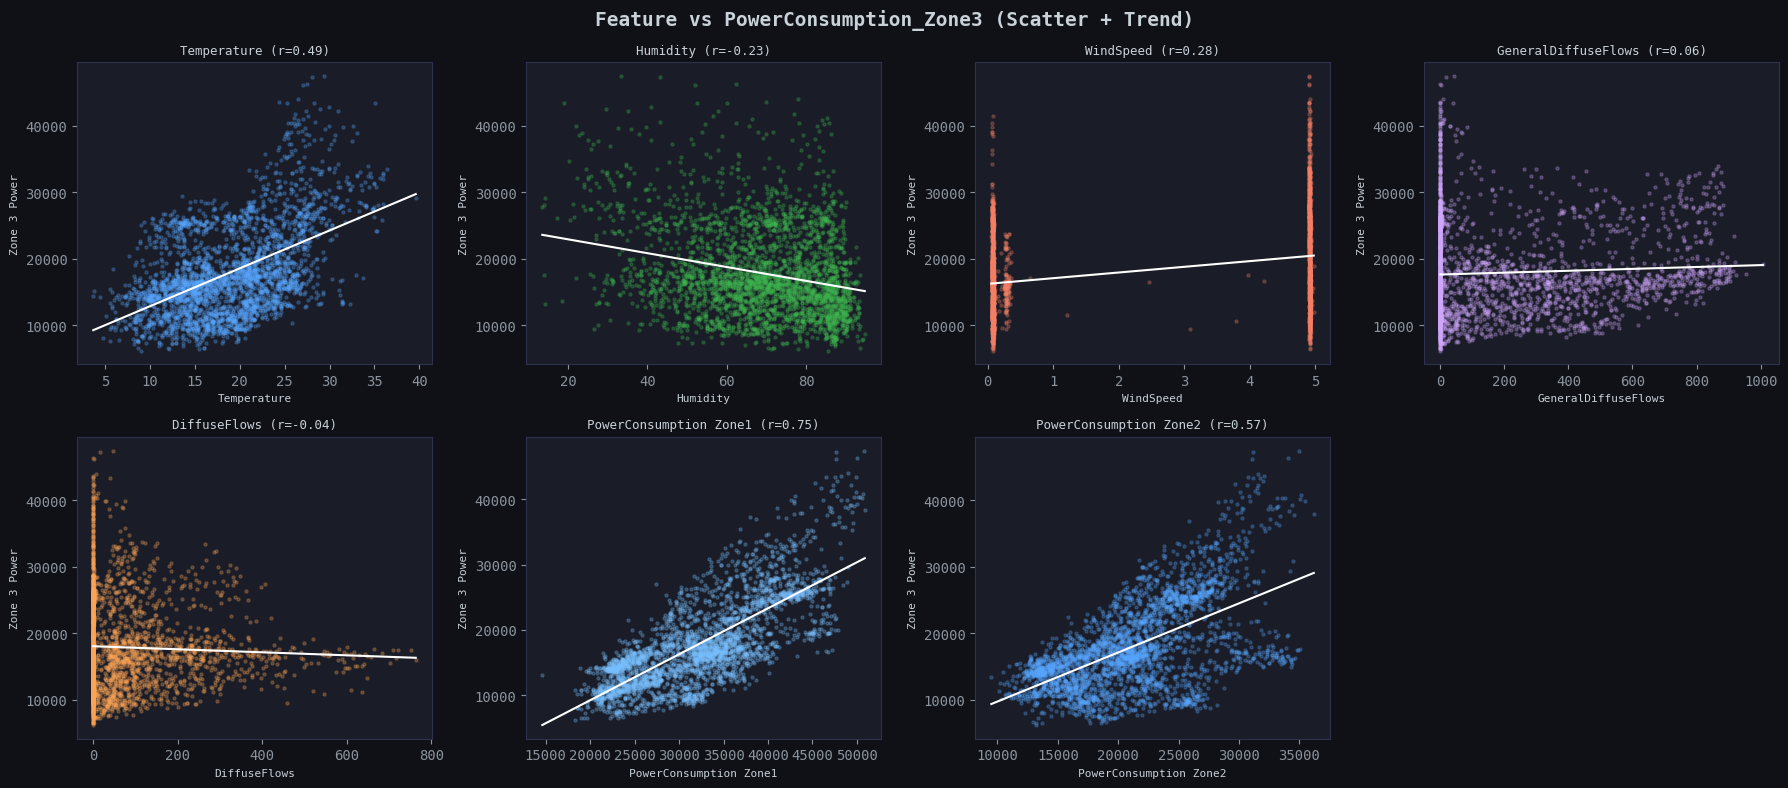

In [23]:
# Scatter Plots: Each Feature vs Zone 3
features_for_scatter = ['Temperature', 'Humidity', 'WindSpeed',
                         'GeneralDiffuseFlows', 'DiffuseFlows',
                         'PowerConsumption_Zone1', 'PowerConsumption_Zone2']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features_for_scatter):
    sample = df.sample(min(3000, len(df)), random_state=42)
    axes[i].scatter(sample[feat], sample['PowerConsumption_Zone3'],
                    alpha=0.25, s=5, color=PALETTE[i % len(PALETTE)])
    # Trend line
    z = np.polyfit(sample[feat].dropna(), sample.loc[sample[feat].notna(), 'PowerConsumption_Zone3'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[feat].min(), sample[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), color='white', linewidth=1.5)
    r = df[[feat, 'PowerConsumption_Zone3']].corr().iloc[0, 1]
    axes[i].set_title(f'{feat.replace("_"," ")} (r={r:.2f})', fontsize=9)
    axes[i].set_xlabel(feat.replace('_', ' '), fontsize=8)
    axes[i].set_ylabel('Zone 3 Power', fontsize=8)

axes[-1].axis('off')
fig.suptitle('Feature vs PowerConsumption_Zone3 (Scatter + Trend)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/09_scatterplots.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 : Zone Comparison

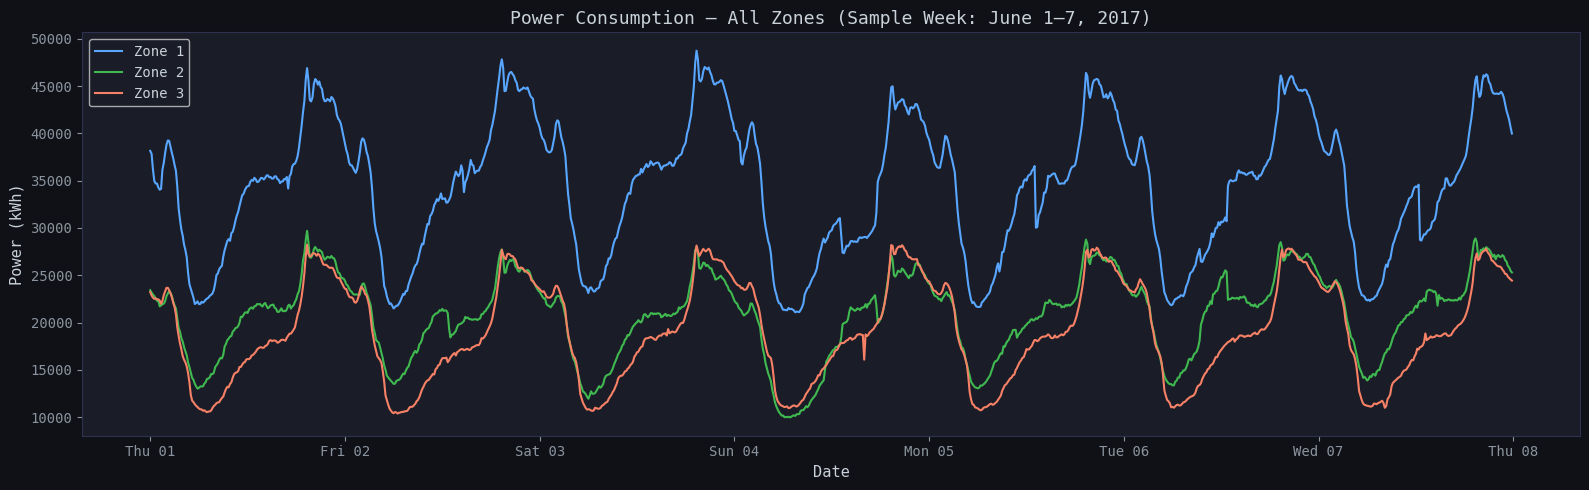

In [24]:
# All 3 Zones Over Time (sampled week)
week_mask = (df['Datetime'] >= '2017-06-01') & (df['Datetime'] < '2017-06-08')
week = df[week_mask]

fig, ax = plt.subplots(figsize=(16, 5))
for zone, color in zip(['Zone1', 'Zone2', 'Zone3'], ['#58a6ff', '#3fb950', '#f78166']):
    ax.plot(week['Datetime'], week[f'PowerConsumption_{zone}'],
            label=f'Zone {zone[-1]}', color=color, linewidth=1.5)
ax.set_title('Power Consumption — All Zones (Sample Week: June 1–7, 2017)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Power (kWh)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
plt.tight_layout()
plt.savefig('plots/10_zone_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7 : EDA Summary & Insights



| # | Insight | Action |
|---|---------|--------|
| 1 | Power consumption exhibits clear **intraday patterns**, with demand varying significantly by hour of day | Extract **Hour** and potentially **Hour²** to capture non-linear daily behavior |
| 2 | Strong **seasonal and monthly variation** is visible in Zone 3 consumption | Extract **Month** and **Season** features |
| 3 | **Weekend and weekday consumption patterns differ**, indicating behavioral effects on electricity usage | Add **IsWeekend** binary feature |
| 4 | **Zone 1 (r = 0.75)** and **Zone 2 (r = 0.57)** show substantial correlation with Zone 3 | Evaluate models both with and without these variables due to potential leakage concerns |
| 5 | **Temperature** has the strongest weather-related relationship with Zone 3 (**r ≈ 0.49**) | Retain Temperature and consider lagged or interaction features |
| 6 | **Humidity** shows a moderate negative correlation with Zone 3 (**r ≈ -0.23**) | Retain as a potentially informative predictor |
| 7 | **WindSpeed** has a weak-to-moderate positive relationship with Zone 3 (**r ≈ 0.28**) | Keep for initial modeling and assess feature importance later |
| 8 | **GeneralDiffuseFlows** and **DiffuseFlows** have very weak linear relationships with Zone 3 | Retain initially; tree-based models may capture non-linear effects |
| 9 | No missing values, duplicate records, timestamp gaps, or identifier columns were found | Dataset is clean and ready for feature engineering |
| 10 | Dataset contains only **one year (2017)** of observations | Use time-aware validation and focus on learning seasonal rather than multi-year trends |

> **Note on Zone 1 & Zone 2:** Although these variables are informative, they are recorded at the same timestamp as Zone 3. If the goal is true future forecasting, including them may introduce information that would not be available at prediction time. Therefore, two model variants should be evaluated:
>
> - **Retrospective model:** includes Zone 1 and Zone 2.
> - **Forecasting model:** excludes Zone 1 and Zone 2.
>
> Results from both approaches should be reported separately.

---
